#Project Description
This project explores image classification using both traditional machine learning and deep learning models. First, we classify MNIST handwritten digits by identifying “lucky digits” (3, 7, 8) using Logistic Regression and Random Forest models.
Next, we build and train a Convolutional Neural Network (CNN) to classify CIFAR-10 images into 10 categories. The model uses data augmentation, batch normalization, and optimization techniques to improve performance.
We evaluate models using accuracy, ROC-AUC, confusion matrices, and visual error analysis, and compare classical ML methods with deep learning performance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix
)

In [ ]:
print("Loading...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(np.float32) / 255.0
y = mnist.target.astype(int)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Loading...
Train: (60000, 784)  Test: (10000, 784)


In [ ]:
# 1. Define Training Transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# 2. Define Test Transforms
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# 3. Create Datasets with the correct variables
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

# 4. Corrected Loaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

# 5. RESTORED CLASSES
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")


100%|██████████| 170M/170M [00:04<00:00, 40.3MB/s]


Train size: 50000 | Test size: 10000


#Q1. Identifying Lucky Numbers

In [ ]:
LUCKY_DIGITS = {3, 7, 8}
y_train_bin = np.array([1 if d in LUCKY_DIGITS else 0 for d in y_train])
y_test_bin  = np.array([1 if d in LUCKY_DIGITS else 0 for d in y_test])

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Lucky fraction in train: {y_train_bin.mean():.3f}')

Train: (60000, 784) | Test: (10000, 784)
Lucky fraction in train: 0.304


In [ ]:
np.random.seed(42)
idx = np.random.choice(60000, 10000, replace=False)
X_cv, y_cv = X_train[idx], y_train_bin[idx]

models = {
    'Logistic Regression': LogisticRegression(max_iter=300, C=0.1, solver='lbfgs', n_jobs=-1),
    'Random Forest':       RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'average_precision', 'accuracy', 'f1']

for name, model in models.items():
    print("\nModel:", name)

    res = cross_validate(model, X_cv, y_cv, cv=cv, scoring=scoring, n_jobs=-1)

    print("ROC-AUC:", round(res["test_roc_auc"].mean(), 4))
    print("PR-AUC :", round(res["test_average_precision"].mean(), 4))


Model: Logistic Regression
ROC-AUC: 0.9268
PR-AUC : 0.8639

Model: Random Forest
ROC-AUC: 0.9872
PR-AUC : 0.9725


In [ ]:
trained = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_bin)
    trained[name] = model

Training Logistic Regression...
Training Random Forest...


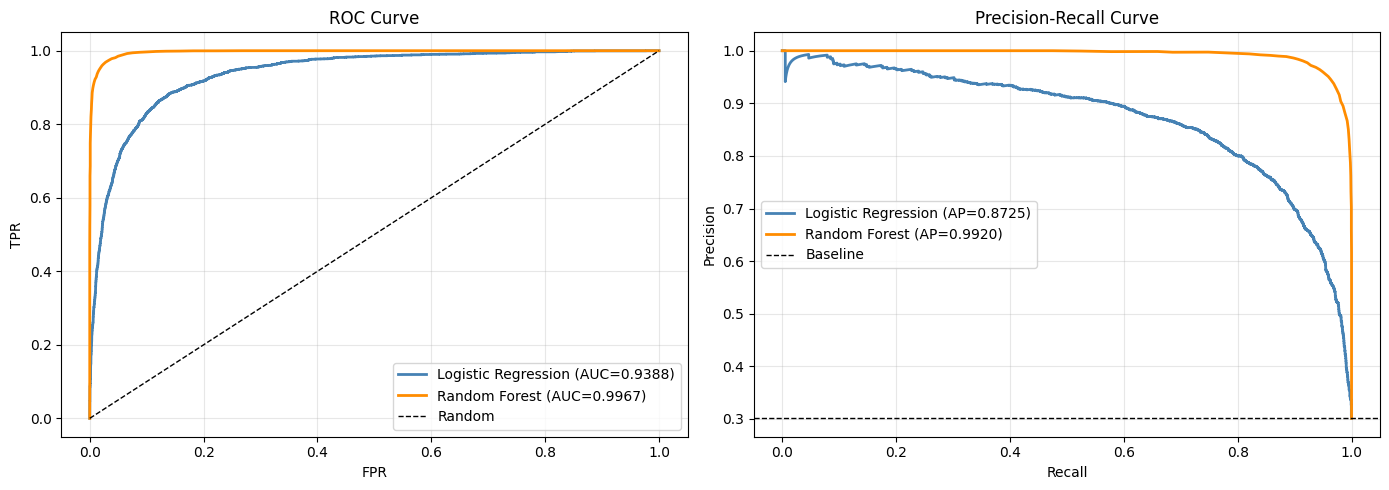

In [ ]:
COLORS = {'Logistic Regression': 'steelblue', 'Random Forest': 'darkorange'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


for name, model in trained.items():
    prob = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test_bin, prob)
    roc_auc = roc_auc_score(y_test_bin, prob)
    ax1.plot(fpr, tpr, color=COLORS[name], lw=2,
             label=f'{name} (AUC={roc_auc:.4f})')

    # PR
    prec, rec, _ = precision_recall_curve(y_test_bin, prob)
    ap = average_precision_score(y_test_bin, prob)
    ax2.plot(rec, prec, color=COLORS[name], lw=2,
             label=f'{name} (AP={ap:.4f})')

# Baseline lines
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax2.axhline(y_test_bin.mean(), color='k', linestyle='--', lw=1,
            label='Baseline')

ax1.set(title='ROC Curve', xlabel='FPR', ylabel='TPR')
ax2.set(title='Precision-Recall Curve', xlabel='Recall', ylabel='Precision')

ax1.legend()
ax2.legend()
ax1.grid(alpha=0.3)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best = trained['Random Forest']
prob = best.predict_proba(X_test)[:, 1]

print("\nPer-digit performance:")

for digit in [3, 7, 8]:
    y_d = (y_test == digit).astype(int)

    print(
        digit,
        "ROC-AUC:", round(roc_auc_score(y_d, prob), 4),
        "PR-AUC:", round(average_precision_score(y_d, prob), 4)
    )


Per-digit performance:
3 ROC-AUC: 0.8849 PR-AUC: 0.3142
7 ROC-AUC: 0.9198 PR-AUC: 0.5186
8 ROC-AUC: 0.8512 PR-AUC: 0.2453


#Q2. CIFAR-10 Architecture Design & Optimization


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import shutil
import os
import matplotlib.pyplot as plt

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.ToTensor()

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=transform_train)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

In [ ]:
class B_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 8x8 -> 4x4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(4096, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = B_CNN().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

EPOCHS = 100

train_loader = DataLoader(
    train_set,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.detach()

    scheduler.step()

    avg_loss = total_loss.item() / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

Epoch 1/100, Loss: 1.7380
Epoch 2/100, Loss: 1.4034
Epoch 3/100, Loss: 1.2809
Epoch 4/100, Loss: 1.2039
Epoch 5/100, Loss: 1.1559
Epoch 6/100, Loss: 1.1155
Epoch 7/100, Loss: 1.0817
Epoch 8/100, Loss: 1.0497
Epoch 9/100, Loss: 1.0222
Epoch 10/100, Loss: 0.9971
Epoch 11/100, Loss: 0.9713
Epoch 12/100, Loss: 0.9516
Epoch 13/100, Loss: 0.9344
Epoch 14/100, Loss: 0.9168
Epoch 15/100, Loss: 0.8970
Epoch 16/100, Loss: 0.8792
Epoch 17/100, Loss: 0.8669
Epoch 18/100, Loss: 0.8468
Epoch 19/100, Loss: 0.8296
Epoch 20/100, Loss: 0.8154
Epoch 21/100, Loss: 0.8079
Epoch 22/100, Loss: 0.7919
Epoch 23/100, Loss: 0.7818
Epoch 24/100, Loss: 0.7691
Epoch 25/100, Loss: 0.7608
Epoch 26/100, Loss: 0.7475
Epoch 27/100, Loss: 0.7403
Epoch 28/100, Loss: 0.7299
Epoch 29/100, Loss: 0.7233
Epoch 30/100, Loss: 0.7167
Epoch 31/100, Loss: 0.7051
Epoch 32/100, Loss: 0.6995
Epoch 33/100, Loss: 0.6925
Epoch 34/100, Loss: 0.6869
Epoch 35/100, Loss: 0.6801
Epoch 36/100, Loss: 0.6762
Epoch 37/100, Loss: 0.6730
Epoch 38/1

Test Accuracy: 0.8484


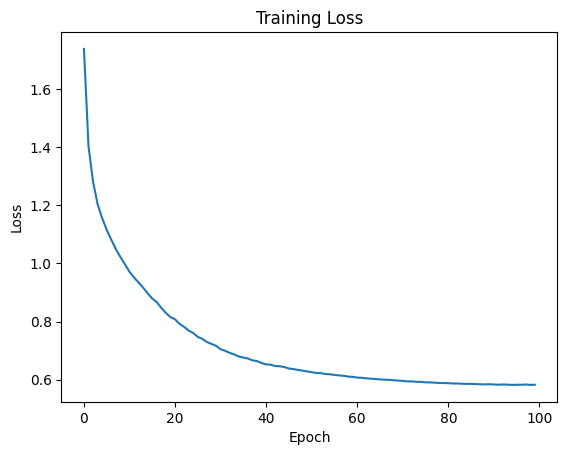

In [ ]:
def accuracy(model, loader):
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

test_acc = accuracy(model, test_loader)
print("Test Accuracy:", round(test_acc, 4))

plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

#Q3. Modeling Saving & Loading


In [ ]:
# 1. Save
torch.save(model.state_dict(), "b_cnn_cifar10.pth")
print("Model saved")

# 2. Fresh model setup
loaded_model = B_CNN().to(device)

# 3. Load
loaded_model.load_state_dict(torch.load("b_cnn_cifar10.pth", map_location=device))
loaded_model.eval()

print("Model loaded")

# 4. Test accuracy
loaded_acc = accuracy(loaded_model, test_loader)
print("Loaded model accuracy:", round(loaded_acc, 4))

Model saved
Model loaded
Loaded model accuracy: 0.8484


#Q4. Visual Analysis & Evaluation

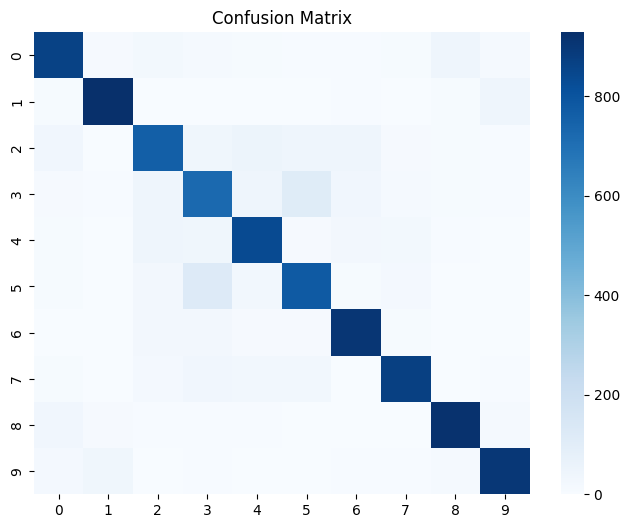

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

loaded_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = loaded_model(x).argmax(1).cpu()

        y_true.append(y)
        y_pred.append(preds)

y_true = torch.cat(y_true)
y_pred = torch.cat(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

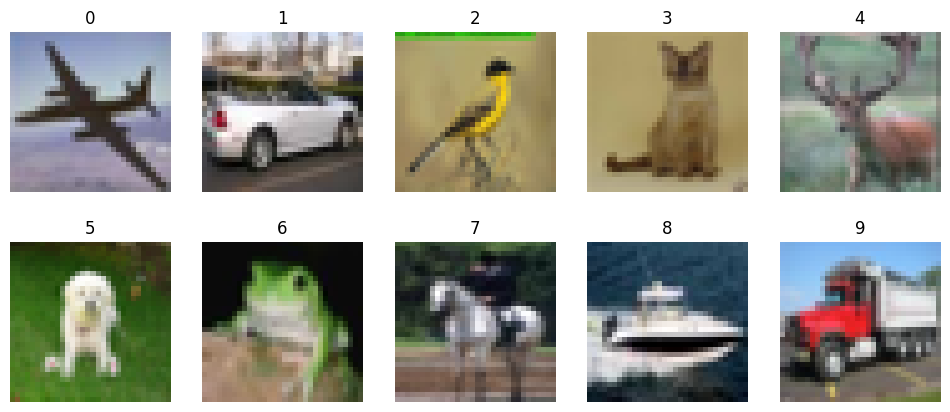

In [ ]:
import torch

loaded_model.eval()

images = []
probs_list = []
labels = []
preds = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = loaded_model(x)
        probs = torch.softmax(out, dim=1)

        images.append(x.cpu())
        probs_list.append(probs.cpu())
        preds.append(out.argmax(1).cpu())
        labels.append(y)

images = torch.cat(images)
probs_list = torch.cat(probs_list)
preds = torch.cat(preds)
labels = torch.cat(labels)

correct = preds == labels

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for cls in range(10):
    mask = correct & (labels == cls)

    if mask.sum() == 0:
        continue

    best_idx = probs_list[mask, cls].argmax().item()
    real_idx = torch.where(mask)[0][best_idx].item()

    img = images[real_idx].permute(1,2,0)

    ax = axes[cls // 5, cls % 5]
    ax.imshow(img)
    ax.set_title(str(cls))
    ax.axis("off")

plt.show()

In [ ]:
from collections import Counter

wrong = preds != labels
pairs = Counter(zip(labels[wrong].tolist(), preds[wrong].tolist()))

print("Top 5 mistakes:")
for (t, p), c in pairs.most_common(5):
    print(t, "→", p, ":", c)

Top 5 mistakes:
5 → 3 : 121
3 → 5 : 111
2 → 4 : 53
2 → 5 : 47
4 → 2 : 46


#Q5. Classification Accuracy

In [ ]:
# ── Q5: Final Classification Accuracy ─-

test_acc = accuracy(model, test_loader)

print("Final Test Accuracy:", round(test_acc, 4))
print("Final Test Accuracy (%):", round(test_acc * 100, 2))

Final Test Accuracy: 0.8484
Final Test Accuracy (%): 84.84
